# Preprocessing Workflow

Clean preprocessing notebook for multiple earthquake catalogs: parse raw catalogs, build processed CSV files, and run basic diagnostics.

## 1) Setup

In [29]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SANS_SERIF_FONTS = ['Arial', 'Helvetica', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': SANS_SERIF_FONTS,
    'mathtext.fontset': 'dejavusans',
})
import geopandas as gpd
from shapely.geometry import Point
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and data/.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
CHINA_SHP_PATH = DATA_DIR / 'ne_10m_admin_0_countries' / 'ne_10m_admin_0_countries.shp'

from src.data.preprocessing import (
    process_synthetic_catlog,
    process_recast_catalog,
    load_and_filter_catalog,
    plot_dt_distributions,
    estimate_mc_max_curvature,
)
import src.features.seismic_features as sf

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'CHINA_SHP_PATH exists: {CHINA_SHP_PATH.exists()}')



PROJECT_ROOT: /root/autodl-tmp/em_eqf
DATA_DIR: /root/autodl-tmp/em_eqf/data
CHINA_SHP_PATH exists: True


## 2) Helpers

In [30]:
def find_single_dat_file(dataset_name: str) -> Path:
    raw_dir = DATA_DIR / dataset_name / 'raw'
    dat_files = sorted(raw_dir.glob('*.dat'))
    if not dat_files:
        raise FileNotFoundError(f'No .dat files found in: {raw_dir}')
    if len(dat_files) > 1:
        raise ValueError(f'Expected one .dat file in {raw_dir}, found: {[p.name for p in dat_files]}')
    return dat_files[0]


def process_cn_catalog_with_ts(dat_file: Path) -> pd.DataFrame:
    column_names = [
        'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
        'Latitude', 'Longitude', 'Depth', 'Magnitude',
    ]
    df = pd.read_csv(dat_file, header=None, names=column_names, sep=r'\s+')

    time_array = np.column_stack([
        df['Year'].astype(int),
        df['Month'].astype(int),
        df['Day'].astype(int),
        df['Hour'].astype(int),
        df['Minute'].astype(int),
        df['Second'].astype(float),
    ])

    jd0 = sf.cal2jd([1970, 1, 1, 0, 0, 0])
    df['t'] = np.array([sf.cal2jd(row) - jd0 for row in time_array])
    df['dt'] = df['t'].diff().fillna(0)
    df['ts'] = pd.to_datetime(
        df[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Second=df['Second']),
        errors='coerce',
    )

    out_df = df[['t', 'Magnitude', 'Latitude', 'Longitude', 'Depth', 'dt', 'ts']].copy()
    save_path = dat_file.with_suffix('.csv')
    out_df.to_csv(save_path, index=False)
    return out_df


def filter_points_with_country_polygon(df: pd.DataFrame, shapefile_path: Path, country_name: str = 'China'):
    world = gpd.read_file(shapefile_path)
    country = world[world['NAME'] == country_name].to_crs(epsg=4326)
    if country.empty:
        raise ValueError(f'Country {country_name!r} not found in shapefile: {shapefile_path}')

    geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
    geo_df = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs='EPSG:4326')
    filtered = geo_df[geo_df.geometry.within(country.geometry.iloc[0])].copy()
    filtered.reset_index(drop=True, inplace=True)
    filtered['dt'] = filtered['t'].diff().fillna(0)

    return geo_df, filtered, country


def plot_before_after_filter(country_gdf, all_points_gdf, filtered_points_gdf):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    country_gdf.plot(ax=axes[0], color='lightblue', edgecolor='black', alpha=0.5)
    all_points_gdf.plot(ax=axes[0], marker='o', color='red', markersize=4, label='All')
    axes[0].set_title('Before Filtering')
    axes[0].legend()

    country_gdf.plot(ax=axes[1], color='lightblue', edgecolor='black', alpha=0.5)
    filtered_points_gdf.plot(ax=axes[1], marker='o', color='green', markersize=4, label='In Country')
    axes[1].set_title('After Filtering')
    axes[1].legend()

    for ax in axes:
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


def add_count_in_time_window(df: pd.DataFrame, time_col: str = 't', window: float = 0.2) -> pd.DataFrame:
    out = df.sort_values(time_col).reset_index(drop=True).copy()
    t_values = out[time_col].to_numpy()

    counts = []
    start_idx = 0
    for i in range(len(t_values)):
        while t_values[i] - t_values[start_idx] > window:
            start_idx += 1
        counts.append(i - start_idx + 1)

    out['count_in_window'] = counts
    return out

## 3) Process `.dat` Catalogs


In [31]:
LOAD_ALL_FROM_CACHE = True  # True: prefer cached CSVs for all catalogs

chinaarray_dat = find_single_dat_file('ChinaArray')
chuandian_dat = find_single_dat_file('ChuanDian')
azdx_taper_dat = find_single_dat_file('AZDX-taper')
azdx_dat = find_single_dat_file('AZDX')

# ChinaArray raw
chinaarray_raw_csv = chinaarray_dat.with_suffix('.csv')
if LOAD_ALL_FROM_CACHE and chinaarray_raw_csv.exists():
    df_chinaarray_raw = pd.read_csv(chinaarray_raw_csv)
    if 'ts' in df_chinaarray_raw.columns:
        df_chinaarray_raw['ts'] = pd.to_datetime(df_chinaarray_raw['ts'], errors='coerce')
    chinaarray_raw_source = f'loaded from {chinaarray_raw_csv.name}'
else:
    df_chinaarray_raw = process_cn_catalog_with_ts(chinaarray_dat)
    chinaarray_raw_source = f'reprocessed from {chinaarray_dat.name}'

# ChuanDian raw
chuandian_csv = chuandian_dat.with_suffix('.csv')
if LOAD_ALL_FROM_CACHE and chuandian_csv.exists():
    df_chuandian = pd.read_csv(chuandian_csv)
    if 'ts' in df_chuandian.columns:
        df_chuandian['ts'] = pd.to_datetime(df_chuandian['ts'], errors='coerce')
    chuandian_source = f'loaded from {chuandian_csv.name}'
else:
    df_chuandian = process_cn_catalog_with_ts(chuandian_dat)
    chuandian_source = f'reprocessed from {chuandian_dat.name}'

# Synthetic catalogs
azdx_taper_csv = azdx_taper_dat.with_suffix('.csv')
if LOAD_ALL_FROM_CACHE and azdx_taper_csv.exists():
    df_azdx_taper = pd.read_csv(azdx_taper_csv)
    azdx_taper_source = f'loaded from {azdx_taper_csv.name}'
else:
    df_azdx_taper = process_synthetic_catlog(str(azdx_taper_dat))
    azdx_taper_source = f'reprocessed from {azdx_taper_dat.name}'

azdx_csv = azdx_dat.with_suffix('.csv')
if LOAD_ALL_FROM_CACHE and azdx_csv.exists():
    df_azdx = pd.read_csv(azdx_csv)
    azdx_source = f'loaded from {azdx_csv.name}'
else:
    df_azdx = process_synthetic_catlog(str(azdx_dat))
    azdx_source = f'reprocessed from {azdx_dat.name}'

print('Processed datasets:')
print(f'- ChinaArray raw: {df_chinaarray_raw.shape} ({chinaarray_raw_source})')
print(f'- ChuanDian: {df_chuandian.shape} ({chuandian_source})')
print(f'- AZDX-taper: {df_azdx_taper.shape} ({azdx_taper_source})')
print(f'- AZDX: {df_azdx.shape} ({azdx_source})')



Processed datasets:
- ChinaArray raw: (1495642, 7) (loaded from china_array.csv)
- ChuanDian: (571131, 7) (loaded from chuandian_2021.csv)
- AZDX-taper: (48806, 6) (loaded from size_3k_stress_0.6_dyn_0.8_mm_5.5_dm_0.5_b_0.4_yr_20k_taper_EQ.csv)
- AZDX: (172846, 6) (loaded from size_3k_stress_0.6_dyn_0.8_mm_5.5_dm_0.5_b_0.4_yr_20k_eq.csv)


In [32]:
REPROCESS_CHINAARRAY_FILTER = False  # True: rerun spatial filtering and overwrite processed_ChinaArray.csv
PLOT_CHINAARRAY_FILTER = False  # True: plot before/after filtering map (extra overhead)

processed_chinaarray_path = DATA_DIR / 'ChinaArray' / 'raw' / 'processed_ChinaArray.csv'

if LOAD_ALL_FROM_CACHE and (not REPROCESS_CHINAARRAY_FILTER) and processed_chinaarray_path.exists():
    df_chinaarray_processed = pd.read_csv(processed_chinaarray_path)
    if 'ts' in df_chinaarray_processed.columns:
        df_chinaarray_processed['ts'] = pd.to_datetime(df_chinaarray_processed['ts'], errors='coerce')

    print(f'Loaded: {processed_chinaarray_path}')
    print(f'ChinaArray in-China events: {len(df_chinaarray_processed)} (cached)')
else:
    geo_all, geo_china, china_boundary = filter_points_with_country_polygon(
        df_chinaarray_raw,
        CHINA_SHP_PATH,
        country_name='China',
    )

    df_chinaarray_processed = geo_china.drop(columns=['geometry']).copy()
    df_chinaarray_processed.to_csv(processed_chinaarray_path, index=False)

    print(f'Saved: {processed_chinaarray_path}')
    print(f'ChinaArray in-China events: {len(df_chinaarray_processed)} / {len(df_chinaarray_raw)}')

    if PLOT_CHINAARRAY_FILTER:
        plot_before_after_filter(china_boundary, geo_all, geo_china)



Loaded: /root/autodl-tmp/em_eqf/data/ChinaArray/raw/processed_ChinaArray.csv
ChinaArray in-China events: 1397558 (cached)


## 4) Process Recast Catalogs

In [33]:
recast_specs = {
    'SCEDC': ('SCEDC', 'SCEDC'),
    'White': ('White', 'White'),
    'SaltonSea': ('QTMSaltonSea', 'SaltonSea'),
    'SanJacinto': ('QTMSanJacinto', 'SanJacinto'),
}

recast_data = {}
for name, (folder, stem) in recast_specs.items():
    csv_path = DATA_DIR / folder / 'raw' / f'{stem}.csv'
    metadata_path = DATA_DIR / folder / 'raw' / 'metadata.pt'

    processed_candidates = sorted((DATA_DIR / folder / 'raw').glob('processed_*.csv'))
    if LOAD_ALL_FROM_CACHE and processed_candidates:
        chosen_processed = processed_candidates[0]
        df_cached = pd.read_csv(chosen_processed)
        if 'ts' in df_cached.columns:
            df_cached['ts'] = pd.to_datetime(df_cached['ts'], errors='coerce')
        recast_data[name] = df_cached
        print(f'- {name}: loaded from {chosen_processed.name}')
    else:
        recast_data[name] = process_recast_catalog(str(csv_path), str(metadata_path))
        print(f'- {name}: reprocessed from {csv_path.name}')

# Convenience aliases
_df = recast_data
df_scedc = _df['SCEDC']
df_white = _df['White']
df_saltonsea = _df['SaltonSea']
df_sanjacinto = _df['SanJacinto']

print('Recast datasets:')
for name, df in recast_data.items():
    print(f'- {name}: {df.shape}')



- SCEDC: loaded from processed_scedc.csv
- White: loaded from processed_white.csv
- SaltonSea: loaded from processed_salton_sea.csv
- SanJacinto: loaded from processed_san_jacinto.csv
Recast datasets:
- SCEDC: (125668, 7)
- White: (134975, 7)
- SaltonSea: (44133, 7)
- SanJacinto: (20790, 7)


## 5) `dt` Distribution Diagnostics

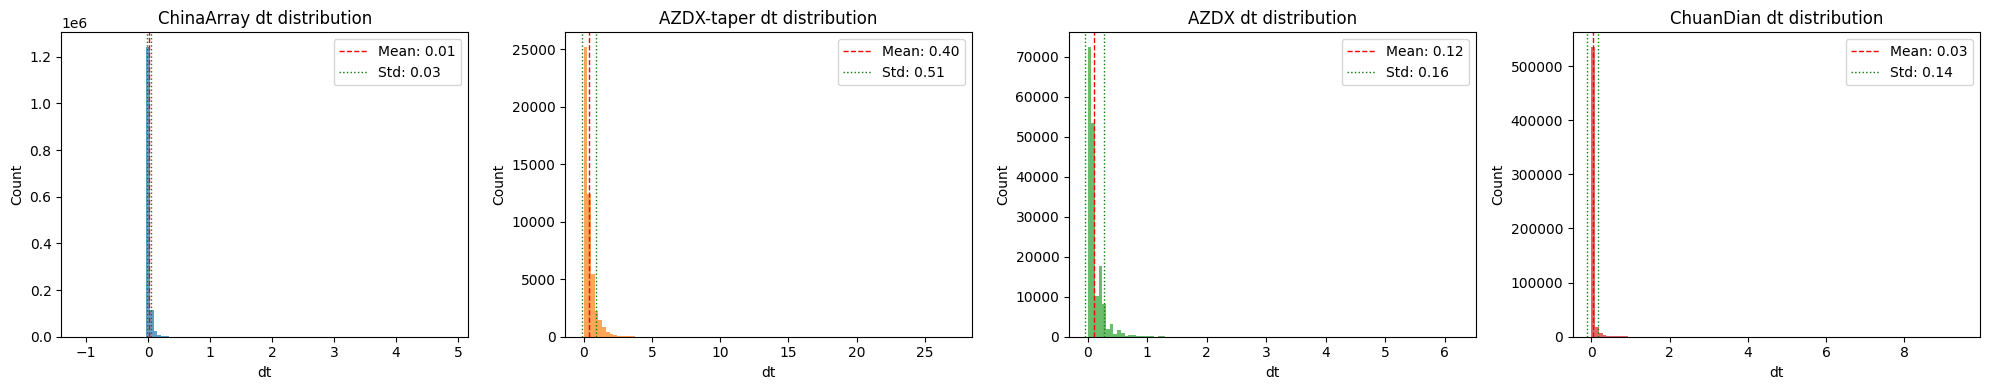

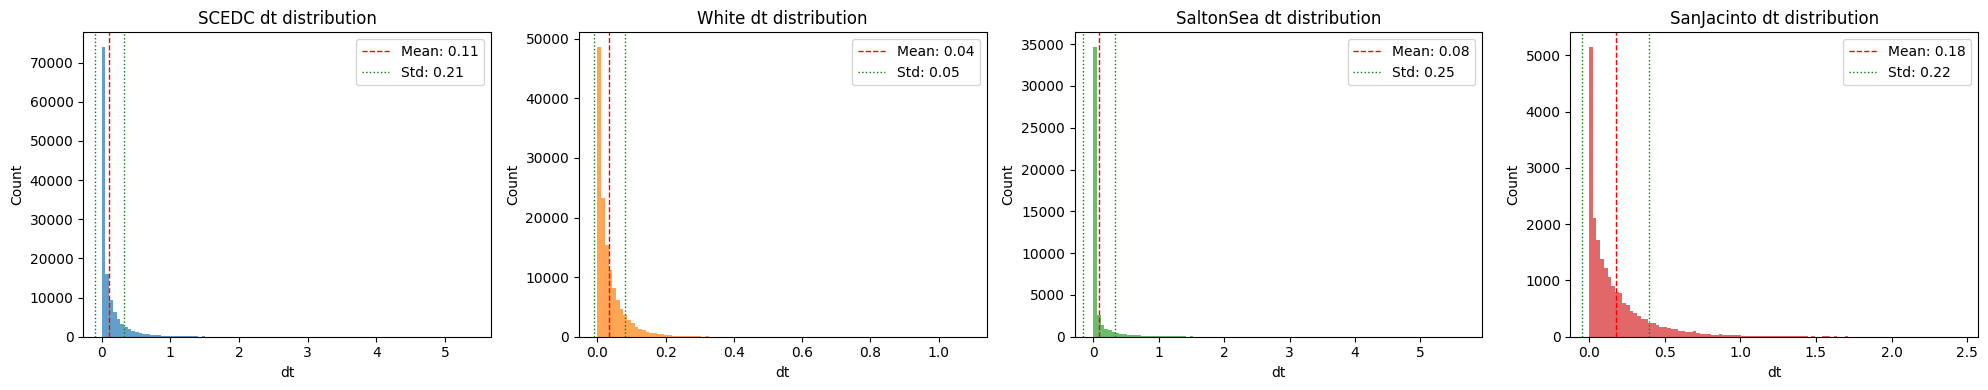

In [34]:
plot_dt_distributions(
    [df_chinaarray_processed, df_azdx_taper, df_azdx, df_chuandian],
    names=['ChinaArray', 'AZDX-taper', 'AZDX', 'ChuanDian'],
    bins=100,
)

plot_dt_distributions(
    [df_scedc, df_white, df_saltonsea, df_sanjacinto],
    names=['SCEDC', 'White', 'SaltonSea', 'SanJacinto'],
    bins=100,
    figsize=(20, 4),
)

## 6) Catalog Magnitude of Completeness (Mc) by Directory


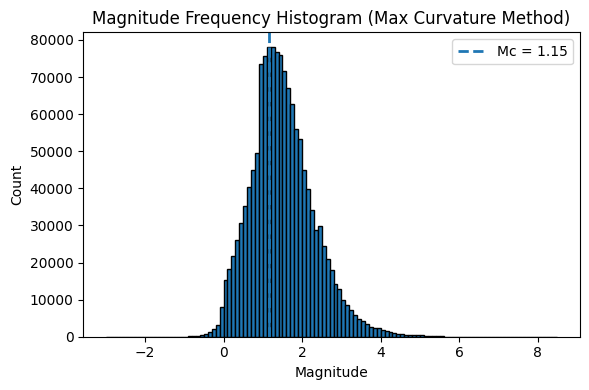

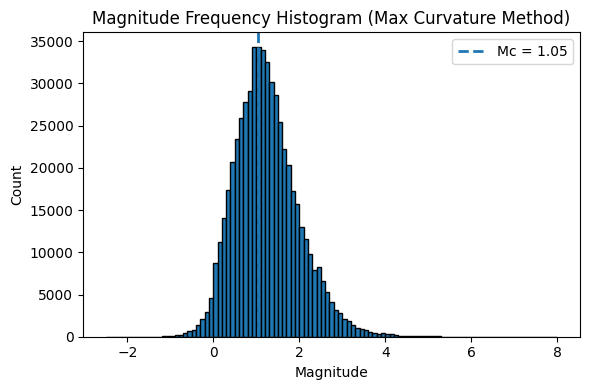

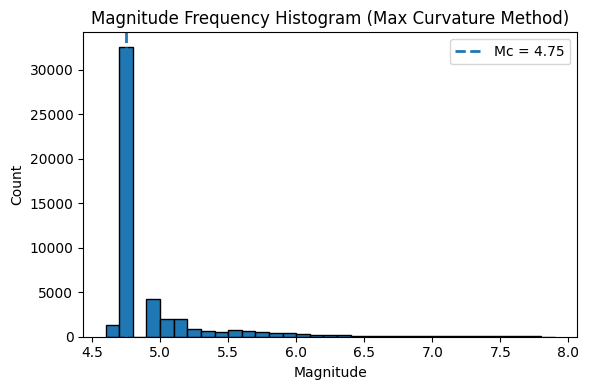

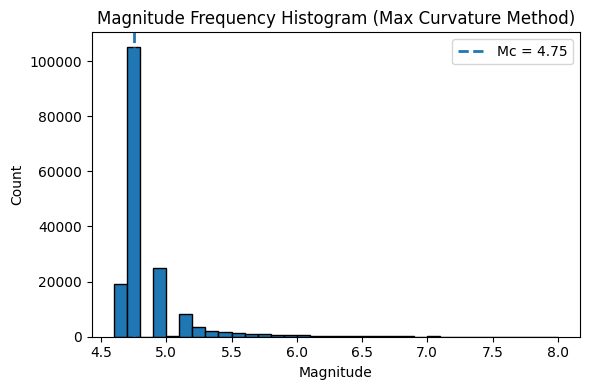

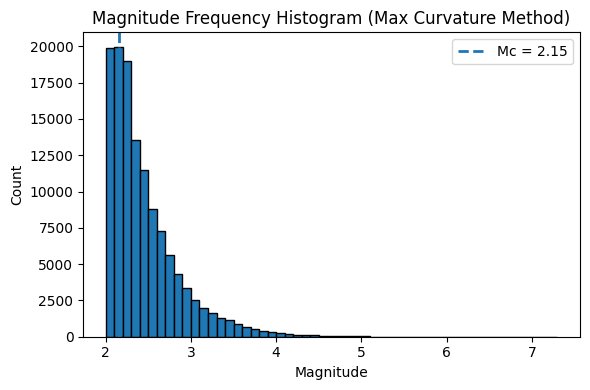

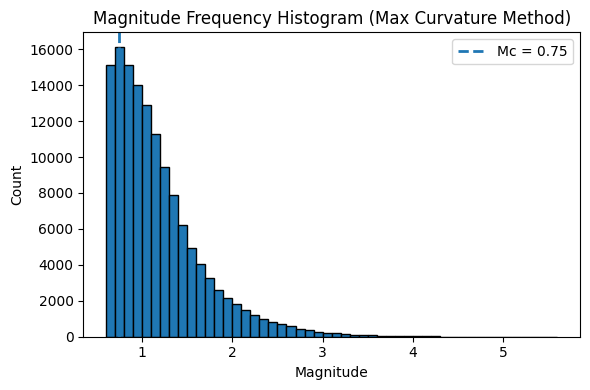

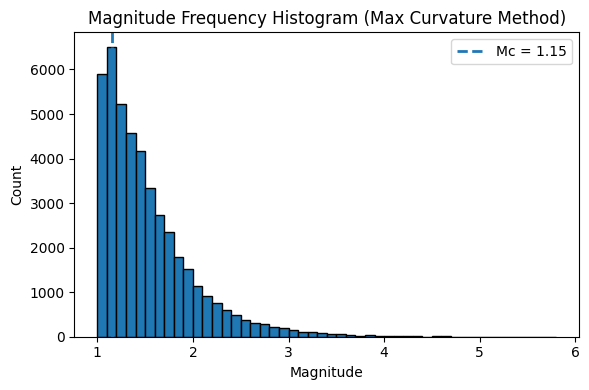

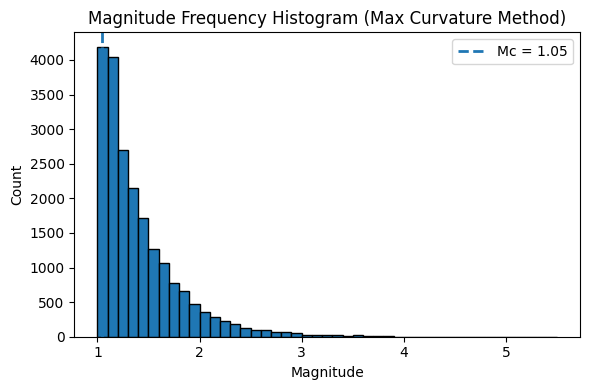

Magnitude completeness (Mc) and b-value (MLE) by directory:


,name,folder,n_events,n_events_M_ge_Mc,mag_min,mag_mean,mag_max,Mc_maxc_dMag0.1,b_mle_M_ge_Mc,b_std_mle_M_ge_Mc
0,AZDX,AZDX,172846,50566,4.698,4.850058,7.914,4.75,0.883515,0.003929
1,AZDX-taper,AZDX-taper,48806,18865,4.698,4.927887,7.848,4.75,0.785068,0.005716
2,ChinaArray,ChinaArray,1397558,949415,-3.000,1.552509,8.500,1.15,0.513216,0.000527
3,ChuanDian,ChuanDian,571131,344862,-2.500,1.294681,8.000,1.05,0.581416,0.000990
4,SCEDC,SCEDC,125668,93316,2.010,2.455935,7.300,2.15,0.891573,0.002919
5,SaltonSea,QTMSaltonSea,44133,34650,1.010,1.530677,5.720,1.15,0.783045,0.004207
6,SanJacinto,QTMSanJacinto,20790,18802,1.010,1.411331,5.430,1.05,0.960481,0.007005
7,White,White,134975,111705,0.610,1.176234,5.540,0.75,0.747776,0.002237


In [35]:
mc_specs = {
    'ChinaArray': ('ChinaArray', df_chinaarray_processed),
    'ChuanDian': ('ChuanDian', df_chuandian),
    'AZDX-taper': ('AZDX-taper', df_azdx_taper),
    'AZDX': ('AZDX', df_azdx),
    'SCEDC': ('SCEDC', df_scedc),
    'White': ('White', df_white),
    'SaltonSea': ('QTMSaltonSea', df_saltonsea),
    'SanJacinto': ('QTMSanJacinto', df_sanjacinto),
}

mag_roundoff_error = 0.1
mc_rows = []
for label, (folder, df_local) in mc_specs.items():
    if 'Magnitude' in df_local.columns:
        mag_col = 'Magnitude'
    elif 'magnitude' in df_local.columns:
        mag_col = 'magnitude'
    else:
        raise KeyError(f'No magnitude column found for {label}. Columns: {list(df_local.columns)}')

    mags = pd.to_numeric(df_local[mag_col], errors='coerce').dropna()
    if mags.empty:
        raise ValueError(f'No valid magnitudes for {label}.')

    mc_val, _, _ = estimate_mc_max_curvature(mags.to_numpy(), bin_width=mag_roundoff_error, plot=True)

    mags_above_mc = mags[mags >= mc_val]
    b_n = int(len(mags_above_mc))
    b_mle = np.nan
    b_std_mle = np.nan

    if b_n >= 2:
        mag_mean_above_mc = float(mags_above_mc.mean())
        denominator = mag_mean_above_mc - float(mc_val) + 0.5 * mag_roundoff_error
        if denominator > 0:
            b_mle = float(np.log10(np.e) / denominator)
            b_std_mle = float(b_mle / np.sqrt(b_n))

    mc_rows.append({
        'name': label,
        'folder': folder,
        'n_events': int(len(mags)),
        'n_events_M_ge_Mc': b_n,
        'mag_min': float(mags.min()),
        'mag_mean': float(mags.mean()),
        'mag_max': float(mags.max()),
        'Mc_maxc_dMag0.1': float(mc_val),
        'b_mle_M_ge_Mc': b_mle,
        'b_std_mle_M_ge_Mc': b_std_mle,
    })

mc_summary = pd.DataFrame(mc_rows).sort_values('name').reset_index(drop=True)
print('Magnitude completeness (Mc) and b-value (MLE) by directory:')
mc_summary



## 7) Additional Checks and Feature Stats

White (Mc=5.0) shape: (4, 8)
White b_mle=0.9316, b_std_mle=0.0273, n=1162
ChinaArray filtered shape: (74441, 8)
ChinaArray dt mean: 0.26303615281857545
ChinaArray dt quantiles:
0.01    0.000419
0.25    0.040410
0.50    0.143851
0.75    0.357373
0.90    0.667940
Name: dt, dtype: float64


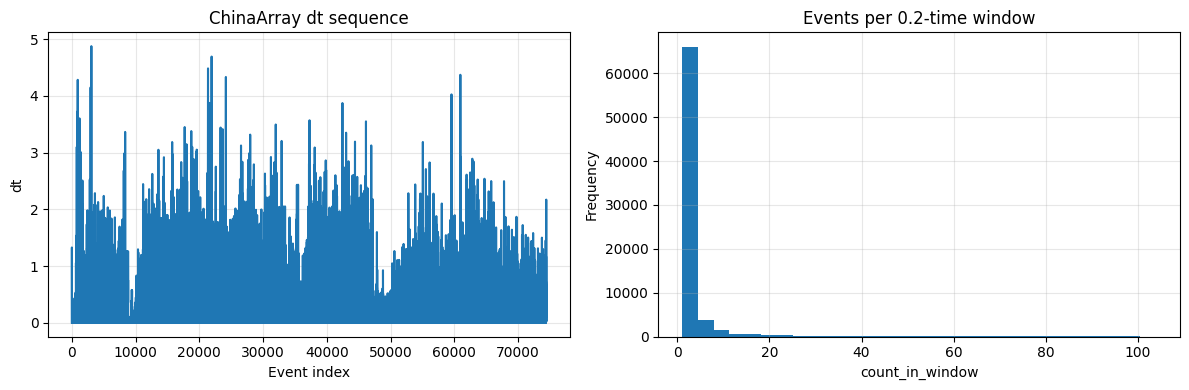

In [36]:
# Example: load filtered White catalog with higher Mc threshold
white_mc5 = load_and_filter_catalog(str(DATA_DIR / 'White'), Mc=5.0)
print('White (Mc=5.0) shape:', white_mc5.shape)

# Gutenberg-Richter b-value (MLE) on White catalog
white_mc1 = load_and_filter_catalog(str(DATA_DIR / 'White'), Mc=1.0)
white_mag_roundoff_error = 0.1
white_mc_for_b = 3.0

white_mags = pd.to_numeric(white_mc1['Magnitude'], errors='coerce').dropna()
white_mags_above_mc = white_mags[white_mags >= white_mc_for_b]
white_b_n = int(len(white_mags_above_mc))
white_b_mle = np.nan
white_b_std_mle = np.nan

if white_b_n >= 2:
    white_mag_mean = float(white_mags_above_mc.mean())
    denominator = white_mag_mean - white_mc_for_b + 0.5 * white_mag_roundoff_error
    if denominator > 0:
        white_b_mle = float(np.log10(np.e) / denominator)
        white_b_std_mle = float(white_b_mle / np.sqrt(white_b_n))

print(f'White b_mle={white_b_mle:.4f}, b_std_mle={white_b_std_mle:.4f}, n={white_b_n}')

# ChinaArray filtered diagnostics
df_chinaarray_filtered = load_and_filter_catalog(str(DATA_DIR / 'ChinaArray'), Mc=3.0)
print('ChinaArray filtered shape:', df_chinaarray_filtered.shape)
print('ChinaArray dt mean:', df_chinaarray_filtered['dt'].mean())
print('ChinaArray dt quantiles:')
print(df_chinaarray_filtered['dt'].quantile([0.01, 0.25, 0.5, 0.75, 0.9]))

df_chinaarray_window = add_count_in_time_window(df_chinaarray_filtered, time_col='t', window=0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_chinaarray_filtered['dt'].to_numpy())
axes[0].set_title('ChinaArray dt sequence')
axes[0].set_xlabel('Event index')
axes[0].set_ylabel('dt')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_chinaarray_window['count_in_window'], bins=30)
axes[1].set_title('Events per 0.2-time window')
axes[1].set_xlabel('count_in_window')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

